In [ ]:
import sys
import os
import importlib
import pandas as pd
import joblib
from sklearn.model_selection import cross_val_score
src_path = os.path.abspath(os.path.join('..', 'src'))

if src_path not in sys.path:
    sys.path.append(src_path)

import src.preprocessing_data.pre_processing as pre_processing_module
import src.feature_engineering.build_features as build_features_module
import src.models.train_model as train_model_module
import src.visualization.visualize as visualize_module

importlib.reload(pre_processing_module)
importlib.reload(build_features_module)
importlib.reload(train_model_module)
importlib.reload(visualize_module)

from src.preprocessing_data.pre_processing import PreProcessor
from src.feature_engineering.build_features import LogisticRegressionFeatureEngineering
from src.models.train_model import BasicRandomForestTraining
from src.visualization.visualize import RandomForestVisualizer

In [ ]:
NROWS = 100000

processor = PreProcessor("../src/data/raw/balanced_10m_reviews.csv")
df = processor.preprocess(nrows=NROWS)

-------------------------
Current Dataframe has 100,000 rows and 20 columns.
No missing values found.

70,211 reviews are positive (70.2%) and 29,789 are negative (29.8%).

On average, authors have played for 13,936 minutes (median: 1,844, longest: 1,613,274).
At the time of writing, authors had played for 6,920 minutes on average (median: 829, longest: 1,280,710).

Reviews are 57.0 words long on average (median: 19, longest: 1,882 words).

Authors have written 35.9 reviews on average (median: 8, most prolific: 10,434).
Authors own 173.5 games on average (median: 0, most: 30,409).

Of the reviews in this dataframe:
  65,814 (65.8%) were purchased on Steam.
  3,554 (3.6%) were received for free.
  12,785 (12.8%) were written during early access.

The current dataframe covers 11,729 unique game(s).
-------------------------


In [ ]:
base_builder = LogisticRegressionFeatureEngineering(df)
base_train_df, base_test_df = base_builder.split_data()

print(f"Training set: {len(base_train_df):,} rows")
print(f"Test set:     {len(base_test_df):,} rows")
print(f"Features:     {base_builder.feature_cols}")

Training set: 80,000 rows
Test set:     20,000 rows
Features:     ['author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access']


In [ ]:
rf_base_trainer = BasicRandomForestTraining(base_train_df, base_test_df, base_builder)
rf_base_trainer.set_features()
rf_base_trainer.train()

baseline_results = rf_base_trainer.evaluate()

print("\nBaseline RF Results (no engineered features):")
for k, v in baseline_results.items():
    print(f"  {k}: {v}")


Baseline RF Results (no engineered features):
  accuracy: 0.7928
  precision: 0.8191256125870519
  recall: 0.9046432132174904
  f1_score: 0.8597631133671743
  confusion_matrix: [[ 3153  2805]
 [ 1339 12703]]


In [ ]:
engineered_builder = LogisticRegressionFeatureEngineering(df)
engineered_builder.votes_ratio()
engineered_builder.playtime_ratio()
engineered_builder.review_length()

eng_train_df, eng_test_df = engineered_builder.split_data()

print(f"Training set: {len(eng_train_df):,} rows")
print(f"Test set:     {len(eng_test_df):,} rows")
print(f"Features:     {engineered_builder.feature_cols}")

Training set: 80,000 rows
Test set:     20,000 rows
Features:     ['author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'votes_ratio', 'playtime_ratio', 'review_length']


In [ ]:
rf_eng_trainer = BasicRandomForestTraining(eng_train_df, eng_test_df, engineered_builder)
rf_eng_trainer.set_features()
rf_eng_trainer.train()

engineered_results = rf_eng_trainer.evaluate()

print("\nRF Results (with engineered features):")
for k, v in engineered_results.items():
    print(f"  {k}: {v}")


RF Results (with engineered features):
  accuracy: 0.8006
  precision: 0.8237794667010176
  recall: 0.9108389118359208
  f1_score: 0.8651244588744589
  confusion_matrix: [[ 3222  2736]
 [ 1252 12790]]


In [ ]:
metrics = ["accuracy", "precision", "recall", "f1_score"]
comparison = pd.DataFrame({
    "Base RF":       [baseline_results[m] for m in metrics],
    "Engineered RF": [engineered_results[m] for m in metrics]
}, index=metrics)

print("Base vs Engineered Features:")
print(comparison.round(4))

Base vs Engineered Features:
           Base RF  Engineered RF
accuracy    0.7928         0.8006
precision   0.8191         0.8238
recall      0.9046         0.9108
f1_score    0.8598         0.8651


In [ ]:
best_params = rf_eng_trainer.tune_hyperparameters()

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
Best F1 score: 0.8634


In [ ]:
rf_eng_trainer.train(best_params)
tuned_results = rf_eng_trainer.evaluate()

print("\nTuned RF Results (engineered features):")
for k, v in tuned_results.items():
    print(f"  {k}: {v}")


Tuned RF Results (engineered features):
  accuracy: 0.8006
  precision: 0.8237794667010176
  recall: 0.9108389118359208
  f1_score: 0.8651244588744589
  confusion_matrix: [[ 3222  2736]
 [ 1252 12790]]


In [ ]:
metrics = ["accuracy", "precision", "recall", "f1_score"]
comparison = pd.DataFrame({
    "Base RF":       [baseline_results[m] for m in metrics],
    "Engineered RF": [engineered_results[m] for m in metrics],
    "Tuned RF":      [tuned_results[m] for m in metrics]
}, index=metrics)

print("Full Comparison:")
print(comparison.round(4))

Full Comparison:
           Base RF  Engineered RF  Tuned RF
accuracy    0.7928         0.8006    0.8006
precision   0.8191         0.8238    0.8238
recall      0.9046         0.9108    0.9108
f1_score    0.8598         0.8651    0.8651


In [ ]:


cv_scores = cross_val_score(
    rf_eng_trainer.model,
    rf_eng_trainer.X_train,
    rf_eng_trainer.y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(f"Cross-validation F1 scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

Cross-validation F1 scores: [0.865  0.8644 0.8653 0.8598 0.8631]
Mean: 0.8635 | Std: 0.0020


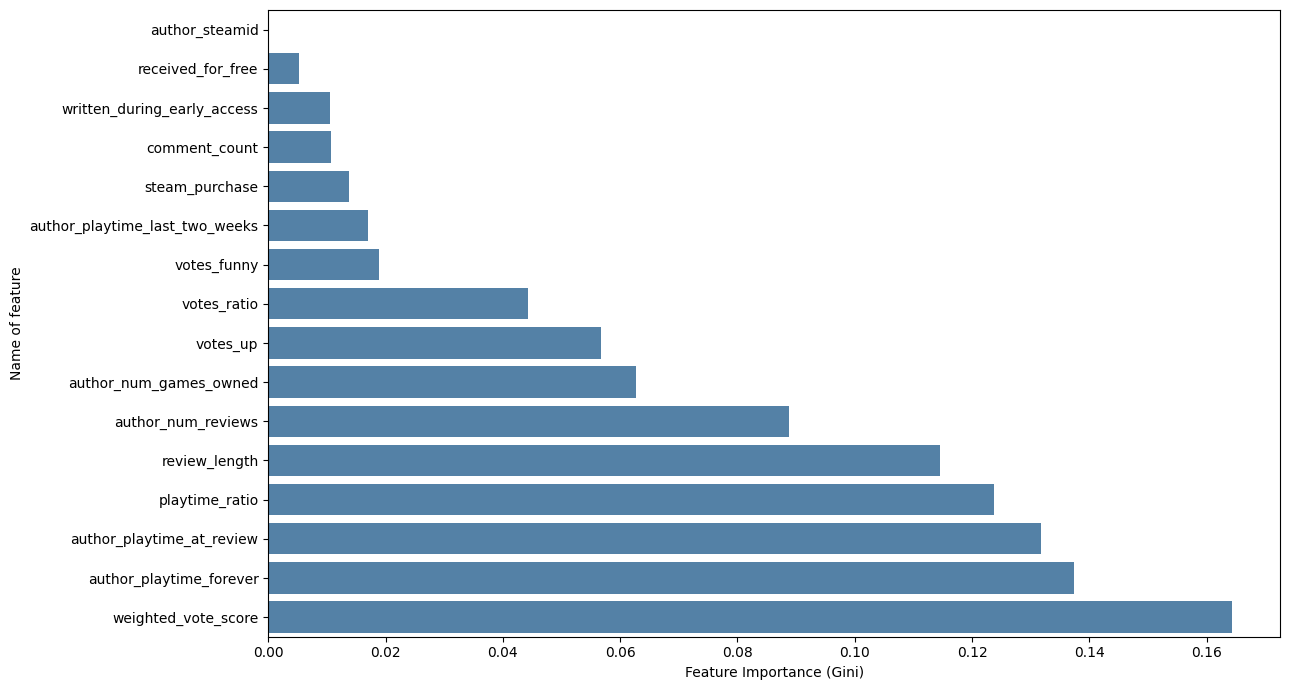

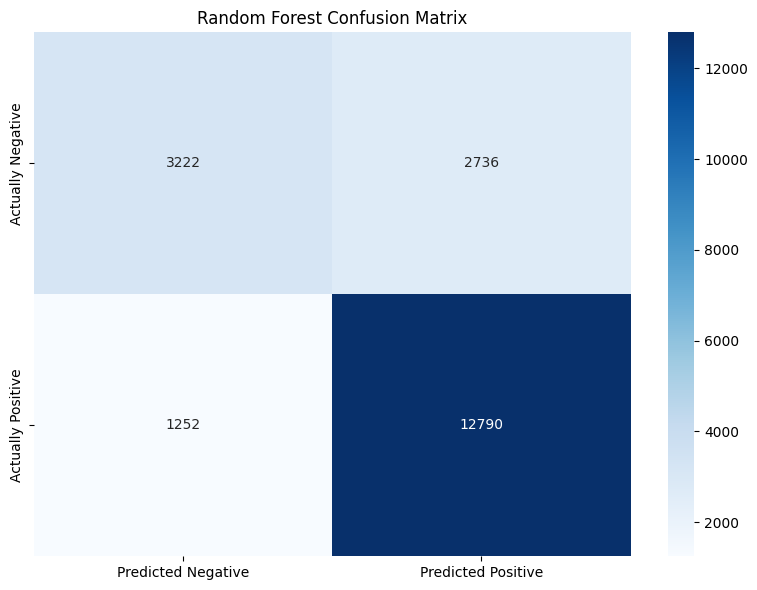

In [ ]:
rf_plot = RandomForestVisualizer(rf_eng_trainer.model, engineered_builder.feature_cols)
rf_plot.plot_all(rf_eng_trainer.y_test, rf_eng_trainer.y_pred)

In [ ]:

joblib.dump(rf_eng_trainer.model, "../src/models/random_forest_model_tuned.pkl")
print(f"Saved tuned model with params: {best_params}")

Saved tuned model with params: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
